# Analyzing different learning rates for DQN

## Importing and setting plotting style

In [51]:
import os
import pandas as pd
import matplotlib.pyplot as plt

In [52]:
plt.style.use('tableau-colorblind10')

## Constructing dataframe

In [53]:
path = os.path.join("..", "data", "evaluation")
checkpoints = ["AdamW1e3", "AdamW1e4", "AdamW25e5", "AdamW1e5", "AdamW5e4"]

In [54]:
data = pd.DataFrame()
columns = ['episode length', 'cumulative reward', 'average reward', 'learning rate']
learning_rates = {
    "AdamW1e3": "1e-3",
    "AdamW1e4": "1e-4",
    "AdamW5e4": "5e-4",
    "AdamW25e5": "2.5e-4",
    "AdamW1e5": "1e-5",
}
for checkpoint in checkpoints:
    df = pd.read_csv(os.path.join(path, f"{checkpoint}.csv"))
    df['learning rate'] = learning_rates[checkpoint]
    data = pd.concat([data, df[columns]])

In [55]:
data.head()

,episode length,cumulative reward,average reward,learning rate
0,700,12.0,0.017143,1e-3
1,919,23.0,0.025027,1e-3
2,683,14.0,0.020498,1e-3
3,656,10.0,0.015244,1e-3
4,641,10.0,0.015601,1e-3


## Removing outliers

In [56]:
Q1_cr = data["cumulative reward"].quantile(0.25)
Q3_cr = data["cumulative reward"].quantile(0.75)

IQR_cr = Q3_cr - Q1_cr
lower_cr = Q1_cr - 1.5 * IQR_cr
upper_cr = Q3_cr + 1.5 * IQR_cr

Q1_ar = data["average reward"].quantile(0.25)
Q3_ar = data["average reward"].quantile(0.75)

IQR_ar = Q3_ar - Q1_ar
lower_ar = Q1_ar - 1.5 * IQR_ar
upper_ar = Q3_ar + 1.5 * IQR_ar

Q1_el = data["episode length"].quantile(0.25)
Q3_el = data["episode length"].quantile(0.75)

IQR_el = Q3_el - Q1_el
lower_el = Q1_el - 1.5 * IQR_el
upper_el = Q3_el + 1.5 * IQR_el

outliers_cr = (data["cumulative reward"] < lower_cr) | (data["cumulative reward"] > upper_cr)
outliers_ar = (data["average reward"] < lower_ar) | (data["average reward"] > upper_ar)
outliers_el = (data["episode length"] < lower_el) | (data["episode length"] > upper_el)
outliers = outliers_ar | outliers_cr | outliers_el

data = data[~outliers]

## Plotting :D

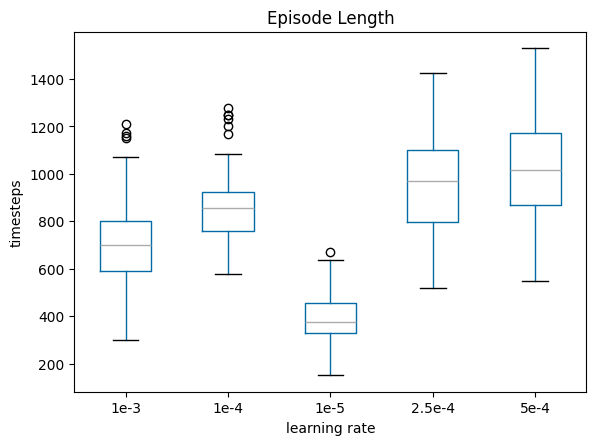

In [57]:
data.boxplot(column="episode length", by="learning rate")
plt.title("Episode Length")
plt.suptitle('')
plt.ylabel("timesteps")
plt.grid(None)
plt.show()

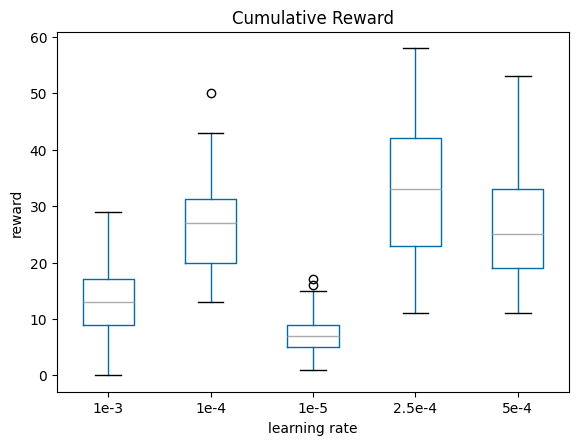

In [58]:
data.boxplot(column="cumulative reward", by="learning rate")
plt.title("Cumulative Reward")
plt.suptitle('')
plt.ylabel("reward")
plt.grid(None)
plt.show()

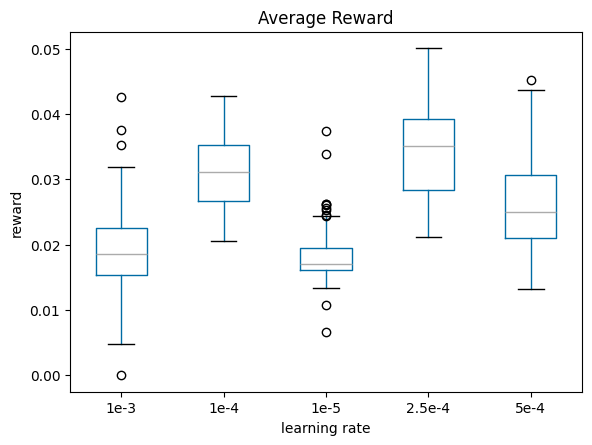

In [59]:
data.boxplot(column="average reward", by="learning rate")
plt.title("Average Reward")
plt.suptitle('')
plt.ylabel("reward")
plt.grid(None)
plt.show()

## Looking at the most promising candidates

In [60]:
checkpoints_1000 = ["AdamW1e4_1000e", "AdamW25e5_1000e"]

data = pd.DataFrame()
columns = ['episode length', 'cumulative reward', 'average reward', 'learning rate']
learning_rates = {
    "AdamW1e4_1000e": "1e-4",
    "AdamW25e5_1000e": "2.5e-4",
}
for checkpoint in checkpoints_1000:
    df = pd.read_csv(os.path.join(path, f"{checkpoint}.csv"))
    df['learning rate'] = learning_rates[checkpoint]
    data = pd.concat([data, df[columns]])

In [61]:
Q1_cr = data["cumulative reward"].quantile(0.25)
Q3_cr = data["cumulative reward"].quantile(0.75)

IQR_cr = Q3_cr - Q1_cr
lower_cr = Q1_cr - 1.5 * IQR_cr
upper_cr = Q3_cr + 1.5 * IQR_cr

Q1_ar = data["average reward"].quantile(0.25)
Q3_ar = data["average reward"].quantile(0.75)

IQR_ar = Q3_ar - Q1_ar
lower_ar = Q1_ar - 1.5 * IQR_ar
upper_ar = Q3_ar + 1.5 * IQR_ar

Q1_el = data["episode length"].quantile(0.25)
Q3_el = data["episode length"].quantile(0.75)

IQR_el = Q3_el - Q1_el
lower_el = Q1_el - 1.5 * IQR_el
upper_el = Q3_el + 1.5 * IQR_el

outliers_cr = (data["cumulative reward"] < lower_cr) | (data["cumulative reward"] > upper_cr)
outliers_ar = (data["average reward"] < lower_ar) | (data["average reward"] > upper_ar)
outliers_el = (data["episode length"] < lower_el) | (data["episode length"] > upper_el)
outliers = outliers_ar | outliers_cr | outliers_el

data = data[~outliers]

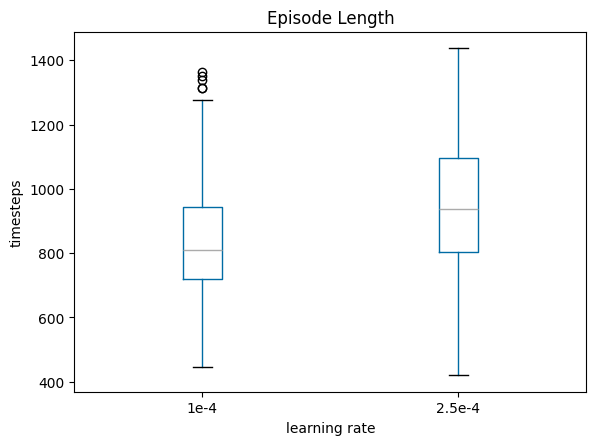

In [62]:
data.boxplot(column="episode length", by="learning rate")
plt.title("Episode Length")
plt.suptitle('')
plt.ylabel("timesteps")
plt.grid(None)
plt.show()

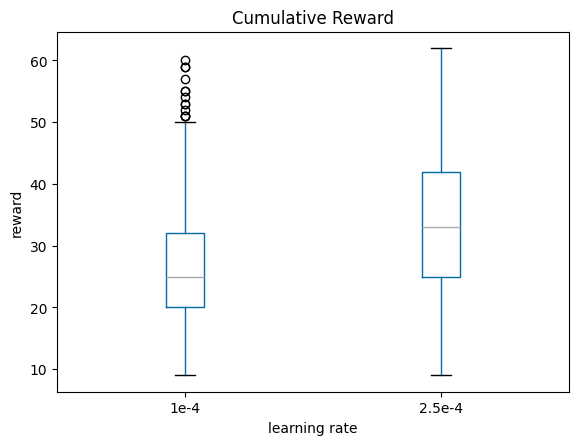

In [63]:
data.boxplot(column="cumulative reward", by="learning rate")
plt.title("Cumulative Reward")
plt.suptitle('')
plt.ylabel("reward")
plt.grid(None)
plt.show()

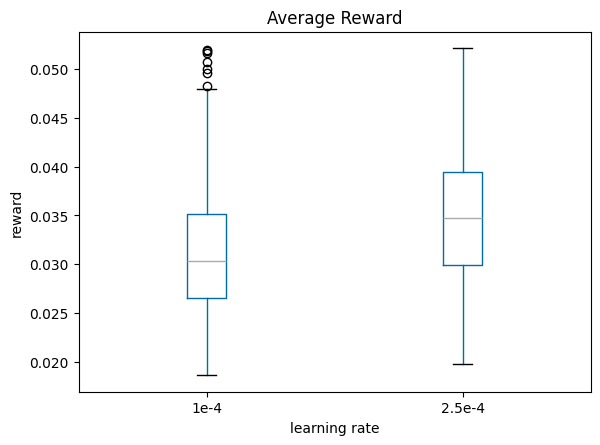

In [64]:
data.boxplot(column="average reward", by="learning rate")
plt.title("Average Reward")
plt.suptitle('')
plt.ylabel("reward")
plt.grid(None)
plt.show()